In [1]:
import jax
import jax.random as jrandom
import jax.tree_util as jtu
import jax.numpy as jnp
from jax import lax

from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, Tsit5, VirtualBrownianTree, SEA, ShARK, PIDController, LevyVal, ALIGN, HalfSolver

import diffrax
import math
import matplotlib.pyplot as plt

from diffrax.solver.ansr import StochasticButcherTableau


def plot_sol(sol, dim=1):
    for i in range(dim):
        plt.plot(sol.ts, sol.ys[:,i], label=f"x{i+1}")
        plt.plot(sol.ts, sol.ys[:,dim+i], label=f"v{i+1}")
    plt.legend()
    plt.show()

In [2]:
def drift(t, y, args):
    gamma, u, grad_f = args
    x, v = y[:2], y[2:]
    d_x = v
    d_v = -gamma * v - u * grad_f(x)
    d_y = jnp.array([d_x, d_v], dtype=jnp.float32).flatten()
    return d_y

def diffusion(t, y, args):
    gamma, u, _ = args
    d_v = jnp.sqrt(2*u*gamma) * jnp.ones((2,), dtype=y.dtype)
    d_y = jnp.concatenate((jnp.zeros((2,2), dtype=jnp.float32), jnp.diag(d_v)), axis=0)
    return d_y

t0, t1 = 0.3, 15
bm1 = VirtualBrownianTree(t0, t1, tol=2**-8, shape=(2,), key=jrandom.PRNGKey(2), compute_stla=True)
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, bm1))
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
gamma = jnp.array([2, 0.2], dtype=jnp.float32)
u = jnp.array([0.5, 5], dtype=jnp.float32)
# u = jnp.float32(2.0)
args = (gamma, u, lambda x: 5 * x)
y0=jnp.array([0, 0, 0, 0], dtype=jnp.float32)

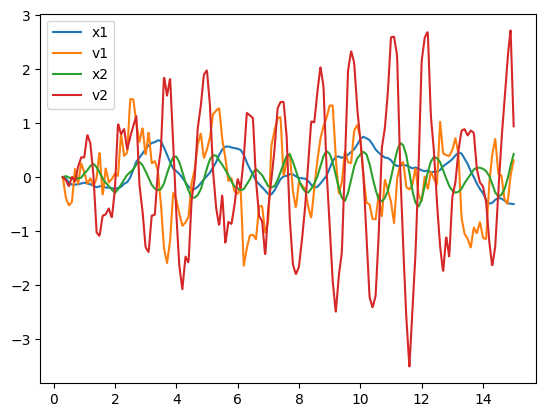

In [3]:
solALIGN = diffeqsolve(terms, ALIGN(0.01), t0, t1, dt0=0.1, y0=y0, args=args, saveat=saveat)
plot_sol(solALIGN, dim=2)

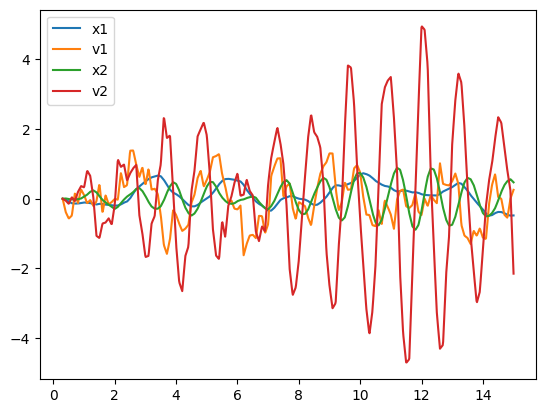

In [9]:
solShARK = diffeqsolve(terms, ShARK(), t0, t1, dt0=0.1, y0=y0, args=args, saveat=saveat)
plot_sol(solShARK, dim=2)

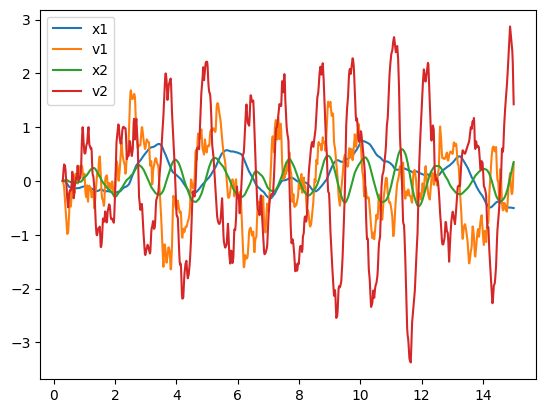

In [7]:
# ShARK adaptive
half_solver = HalfSolver(ShARK())
controller = PIDController(pcoeff=0.1, icoeff=0.3, rtol=0.005, atol=0.001)
solShARK_PID = diffeqsolve(terms, half_solver, t0, t1, dt0=0.1, y0=y0, args=args, saveat=saveat, stepsize_controller=controller)
plot_sol(solShARK_PID, dim=2)

In [ ]:
solSEA = diffeqsolve(terms, SEA(), t0, t1, dt0=0.1, y0=y0, args=args, saveat=saveat)
plot_sol(solSEA, dim=2)

In [ ]:
solEuler = diffeqsolve(terms, Euler(), t0, t1, dt0=0.1, y0=y0, args=args,
                    saveat=saveat)
plot_sol(solEuler, dim=2)

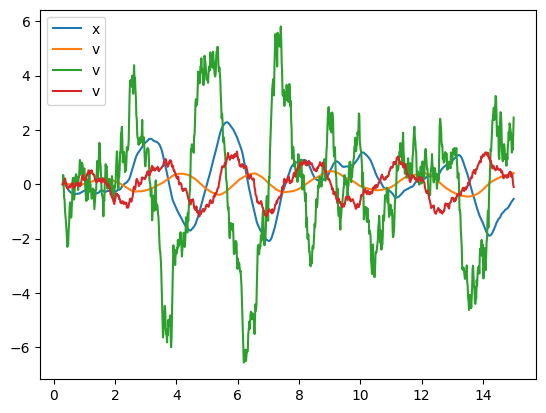

In [8]:
solPrecise = diffeqsolve(terms, Euler(), t0, t1, dt0=0.005, y0=y0, args=args,
                    saveat=saveat)
plot_sol(solPrecise, dim=2)

In [ ]:
stepsize_controller = PIDController(rtol=0.003, atol=0.001)
solALIGN_PID = diffeqsolve(terms, ALIGN(), t0, t1, dt0=1.0, y0=y0, args=args, saveat=saveat, stepsize_controller=stepsize_controller)
plot_sol(solALIGN_PID)

In [ ]:
print(f"Euler:    {solEuler.ys[-1]}")
print(f"SEA:      {solSEA.ys[-1]}")
print(f"ShARK:    {solShARK.ys[-1]}")
print(f"ALIGN     {solALIGN.ys[-1]}")
print(f"PID:      {solALIGN_PID.ys[-1]}")
print(f"Precise:  {solPrecise.ys[-1]}")